Bank Customer churn

In [129]:
import pandas as pd

df=pd.read_csv(r'E:\Customer_churn\Data\Customer-Churn-Records.csv')


In [130]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [132]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

In [133]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Complain','Satisfaction Score', 'Point Earned', 'Card Type'], inplace=True)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [135]:
X=df.drop('Exited', axis=1)
y=df['Exited']

In [136]:
X= pd.get_dummies(X,drop_first=True)

In [137]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [138]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [139]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [140]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [141]:
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.models import Sequential

models=Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [142]:
models.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [143]:
history=models.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7555 - loss: 0.5692 - val_accuracy: 0.8056 - val_loss: 0.4786
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8039 - loss: 0.4605 - val_accuracy: 0.8144 - val_loss: 0.4329
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8159 - loss: 0.4326 - val_accuracy: 0.8150 - val_loss: 0.4152
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.4172 - val_accuracy: 0.8219 - val_loss: 0.4027
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8289 - loss: 0.4040 - val_accuracy: 0.8263 - val_loss: 0.3902
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8366 - loss: 0.3918 - val_accuracy: 0.8400 - val_loss: 0.3772
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8452 - loss: 0.3803 - val_accuracy: 0.8469 - val_loss: 0.3650
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8453 - loss: 0.3708 - val_accu

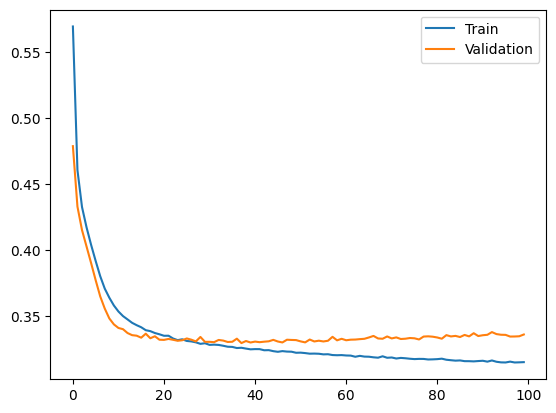

In [144]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend()
plt.show()

In [145]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

model_reg=Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),Dropout(0.4),
    Dense(16, activation='relu',kernel_regularizer=l2(0.001)),Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [146]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [147]:
model_reg.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [148]:
model_reg.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2,callbacks=[early_stop])

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6894 - loss: 0.6311 - val_accuracy: 0.8037 - val_loss: 0.4977
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7923 - loss: 0.5122 - val_accuracy: 0.8044 - val_loss: 0.4652
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7987 - loss: 0.4903 - val_accuracy: 0.8069 - val_loss: 0.4486
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8067 - loss: 0.4752 - val_accuracy: 0.8206 - val_loss: 0.4371
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8081 - loss: 0.4693 - val_accuracy: 0.8275 - val_loss: 0.4300
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8134 - loss: 0.4593 - val_accuracy: 0.8306 - val_loss: 0.4229
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8223 - loss: 0.4540 - val_accuracy: 0.8350 - val_loss: 0.4156
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8234 - loss: 0.4412 - val_accu

Model Evaluation

In [149]:
from sklearn.metrics import classification_report

y_pred= (model_reg.predict(X_test_scaled) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1592
           1       0.79      0.50      0.61       408

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [150]:
y_prob= model_reg.predict(X_test_scaled).ravel()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [151]:
threshold=0.35
y_pred_35= (y_prob >= threshold).astype(int)

In [152]:
print(classification_report(y_test, y_pred_35))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1592
           1       0.65      0.60      0.63       408

    accuracy                           0.85      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.85      0.85      0.85      2000



In [153]:
import numpy as np
from sklearn.metrics import f1_score

thresholds= np.arange(0.2, 0.6, 0.05)
for t in thresholds:
    y_pred_t= (y_prob >= t).astype(int)
    f1=f1_score(y_test, y_pred_t)
    print(f"threshold:{t:.2f} f1_score:{f1:.3f}")

threshold:0.20 f1_score:0.597
threshold:0.25 f1_score:0.621
threshold:0.30 f1_score:0.626
threshold:0.35 f1_score:0.628
threshold:0.40 f1_score:0.623
threshold:0.45 f1_score:0.617
threshold:0.50 f1_score:0.608
threshold:0.55 f1_score:0.564


In [154]:
from sklearn.utils.class_weight import compute_class_weight

class_weight=compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y= y_train
)
class_weight_dict= {
    0:class_weight[0],
    1:class_weight[1]
}
class_weight_dict

{0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}

In [155]:
history_weighted=model_reg.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8008 - loss: 0.5240 - val_accuracy: 0.7919 - val_loss: 0.4753
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7845 - loss: 0.5057 - val_accuracy: 0.8050 - val_loss: 0.4595
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7906 - loss: 0.5098 - val_accuracy: 0.8012 - val_loss: 0.4766
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7936 - loss: 0.5026 - val_accuracy: 0.7781 - val_loss: 0.4934
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7834 - loss: 0.5053 - val_accuracy: 0.7894 - val_loss: 0.4787


In [156]:
y_prob_w= model_reg.predict(X_test_scaled).ravel()
y_pred_w= (y_prob_w >= 0.5).astype(int)

print(classification_report(y_test, y_pred_w))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1592
           1       0.51      0.76      0.61       408

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



In [157]:
import numpy as np
from sklearn.metrics import f1_score

thresholds= np.arange(0.2, 0.6, 0.05)
for t in thresholds:
    y_pred_tw= (y_prob_w >= t).astype(int)
    f1=f1_score(y_test, y_pred_tw)
    print(f"threshold:{t:.2f} f1_score:{f1:.3f}")

threshold:0.20 f1_score:0.431
threshold:0.25 f1_score:0.474
threshold:0.30 f1_score:0.509
threshold:0.35 f1_score:0.531
threshold:0.40 f1_score:0.563
threshold:0.45 f1_score:0.591
threshold:0.50 f1_score:0.608
threshold:0.55 f1_score:0.620


In [158]:
feature_names= X_train.columns.tolist()
feature_names

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Male']

In [159]:
model_reg.save(r'E:\Customer_churn\Models\churn_ann_model.keras')

In [160]:
from tensorflow.keras.models import load_model
model= load_model(r"E:\Customer_churn\Models\churn_ann_model.keras",compile=False)

In [161]:
import joblib

joblib.dump(sc, r"E:\Customer_churn\Models\scaler.pkl")